# 04 — Универсальный runner контролируемых экспериментов

Этот notebook **не содержит код конкретной идеи**. Он загружает выбранный
Git-версионируемый модуль из `src/ml_project/experiments/`, пересчитывает
явный baseline/champion reference и candidate на одинаковых folds, сохраняет графики,
артефакты, карточку и реестры.

| Что меняется между экспериментами | Где хранится |
|---|---|
| Выбранный модуль | `src/ml_project/experiment_config.py` |
| Родитель, гипотеза, критерии, candidate-data и candidate-models | отдельный модуль `src/ml_project/experiments/exp_xxx_*.py` |
| Общий CV, метрики и baseline | `baseline_config.BASELINE` |
| Автоматический отчёт и ручное объяснение | карточка `experiments/EXP-xxx ...md` |

> [!important]
> Не добавляйте экспериментальные ячейки в этот notebook. Незавершённую
> функцию сначала разработайте в локальном `notebooks/workbench/`, затем
> перенесите в experiment-модуль. Этот notebook — строгий официальный runner.

[Карточка проекта: как начать новый эксперимент](../README.md#как-начать-новый-эксперимент)


## 0. Перед стартом

- [ ] Baseline сохранён и понятен.
- [ ] В `experiment_config.py` выбран нужный `EXPERIMENT_MODULE`.
- [ ] Draft из локального workbench перенесён в experiment-модуль.
- [ ] В модуле нет `CHANGE ME` и `NotImplementedError`.
- [ ] Заранее заданы `primary_improvement_min` и `metric_guardrails`.
- [ ] Новый смысл имеет уникальные `experiment_id`, `run_name` и модуль.

Если модуль ещё не готов, используйте созданный launcher-ом workbench. После
переноса реализации выполняйте `Restart Kernel → Run All`.


In [1]:
from pathlib import Path
import importlib
import sys

from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").exists() and (candidate / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.config as project_config
import ml_project.baseline_config as baseline_config
import ml_project.experiment_config as experiment_config
import ml_project.modeling as modeling_tools
import ml_project.experiment as experiment_tools

print(f"Корень проекта: {PROJECT_ROOT}")


Корень проекта: D:\Projects\Titanik-ML-project


## 1. Перечитать выбранный эксперимент

Эта ячейка загружает готовый объект `EXPERIMENT` и функции candidate-data /
candidate-models из отдельного модуля. Скрытой сборки конфигурации нет.


In [2]:
project_config = importlib.reload(project_config)
baseline_config = importlib.reload(baseline_config)
experiment_config = importlib.reload(experiment_config)
modeling_tools = importlib.reload(modeling_tools)
experiment_tools = importlib.reload(experiment_tools)

DATASETS = project_config.DATASETS
FEATURE_GROUPS = project_config.FEATURE_GROUPS
INFERENCE_DATASET = project_config.INFERENCE_DATASET
KEY = project_config.KEY
RAW_DIR = project_config.RAW_DIR
TARGET = project_config.TARGET
TRAIN_DATASET = project_config.TRAIN_DATASET

# initial_settings — фиксированный контракт EXP-001 для schema, metrics и CV.
# Parent-эксперименты создают из него эффективные reference_settings.
initial_settings = baseline_config.BASELINE
experiment_definition = experiment_tools.load_experiment(
    experiment_config.EXPERIMENT_MODULE
)
experiment_settings = experiment_definition.settings
module_stem = experiment_definition.module_name.rsplit(".", 1)[-1]
module_slug = module_stem.split("_", 2)[-1]
workbench_path = (
    PROJECT_ROOT / "notebooks/workbench"
    / f"{experiment_settings.experiment_id}_{module_slug}.ipynb"
)

modeling_tools.validate_modeling_settings(initial_settings)
experiment_tools.validate_settings(experiment_settings)
experiment_lineage = experiment_tools.resolve_experiment_lineage(
    experiment_definition
)
display(experiment_tools.settings_report(experiment_settings))
print("Модуль:", experiment_definition.module_name)
print(
    "Цепочка:",
    "EXP-001 → "
    + " → ".join(
        item.settings.experiment_id
        for item in [*reversed(experiment_lineage), experiment_definition]
    ),
)
print("Файл:", experiment_definition.source_path.relative_to(PROJECT_ROOT))
print("Локальный workbench:", workbench_path.relative_to(PROJECT_ROOT))
print("SHA-256 кода:", experiment_definition.source_sha256)


,section,parameter,value
0,identity,experiment_id,EXP-011
1,identity,experiment_title,SexPlcass_V2
2,pre-registration,hypothesis,"if сделаю категориальный признак SexPclass, t..."
3,pre-registration,change_description,Объединить признаки Pclass и Sex в один приз
4,pre-registration,success_criterion,Primary improvement >= +0.0050; add explicit m...
5,pre-registration,primary_improvement_min,0.005
6,pre-registration,metric_guardrails,"{'Balanced accuracy': 0.0, 'Recall': -0.01, 'F..."
7,comparison,reference_model,champion_reference
8,comparison,parent_experiment_module,ml_project.experiments.exp_003_family_size
9,comparison,primary_candidate,candidate


Модуль: ml_project.experiments.exp_011_sexplcass_v2
Цепочка: EXP-001 → EXP-002 → EXP-003 → EXP-011
Файл: src\ml_project\experiments\exp_011_sexplcass_v2.py
Локальный workbench: notebooks\workbench\EXP-011_sexplcass_v2.ipynb
SHA-256 кода: 82edb29c4784b7963c1a44264134d8d2b680215443c8ecbaa70fdb3c589ce561


## 2. Загрузить неизменяемый data contract

Inference загружается только для проверки схемы и не участвует в оценке.


In [3]:
catalog = DataCatalog(PROJECT_ROOT, RAW_DIR, DATASETS)
catalog.validate()
train = catalog.load(TRAIN_DATASET)
inference = catalog.load(INFERENCE_DATASET) if INFERENCE_DATASET else None

train_file = catalog.file_report().set_index("dataset").loc[TRAIN_DATASET]
dataset_version = str(train_file["sha256"])
print(f"Train: {train.shape[0]} строк × {train.shape[1]} столбцов")
print("Dataset SHA-256:", dataset_version)


Train: 891 строк × 12 столбцов
Dataset SHA-256: 7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f


## 3. Автоматически восстановить baseline/champion reference

Reference всегда пересчитывается на тех же folds: из `baseline_config.BASELINE`
для независимого эксперимента либо из primary candidate явно принятого родителя.
Старый CSV никогда не используется как модель.


In [4]:
raw_inference_plan = modeling_tools.resolve_feature_plan(
    train, FEATURE_GROUPS, target=TARGET, key=KEY, settings=initial_settings,
)
if inference is not None:
    modeling_tools.validate_inference_schema(
        inference,
        raw_inference_plan,
        strict=initial_settings.require_inference_features,
    )
reference_context = experiment_tools.prepare_experiment_parent(
    experiment_definition,
    train,
    FEATURE_GROUPS,
    initial_settings,
)
# reference_settings — настройки принятого чемпиона после всей parent-цепочки.
reference_settings = reference_context.settings
reference_plan = modeling_tools.resolve_feature_plan(
    reference_context.frame,
    reference_context.feature_groups,
    target=TARGET,
    key=KEY,
    settings=reference_settings,
)
reference_data = modeling_tools.prepare_training_data(
    reference_context.frame,
    target=TARGET,
    plan=reference_plan,
    settings=reference_settings,
)
scoring_plan = modeling_tools.resolve_scoring_plan(
    PROJECT_ROOT, initial_settings,
)
cv, resolved_cv_strategy = modeling_tools.build_cv_splitter(
    initial_settings, reference_data.y,
)
cv_description = modeling_tools.cv_protocol_description(
    initial_settings, resolved_cv_strategy,
)
reference_preprocessor = modeling_tools.build_tabular_preprocessor(
    reference_settings, reference_plan,
)
reference_pipeline = experiment_tools.build_experiment_reference(
    experiment_definition,
    reference_preprocessor,
    reference_settings,
)
print("Reference:", experiment_settings.reference_model)
print("Validation:", cv_description)
display(scoring_plan.to_frame())


Reference: champion_reference
Validation: stratified_kfold(n_splits=5, shuffle=True, seed=42)


,role,report_name,sklearn_scorer,direction
0,primary,accuracy,accuracy,maximize
1,secondary,Balanced accuracy,balanced_accuracy,maximize
2,secondary,Precision,precision,maximize
3,secondary,Recall,recall,maximize
4,secondary,F1,f1,maximize
5,secondary,ROC-AUC,roc_auc,maximize


## 4. Выполнить candidate-data hook

Код находится в выбранном experiment-модуле. Диагностические таблицы можно
вернуть через `ExperimentData.diagnostics`; они отобразятся автоматически.


In [5]:
candidate_data = experiment_tools.prepare_experiment_candidate(
    experiment_definition,
    train,
    FEATURE_GROUPS,
    initial_settings,
)
# candidate_settings — reference_settings после единственного изменения EXP.
candidate_settings = candidate_data.settings
for diagnostic_name, diagnostic in candidate_data.diagnostics.items():
    print(diagnostic_name)
    display(diagnostic)

candidate_plan = modeling_tools.resolve_feature_plan(
    candidate_data.frame,
    candidate_data.feature_groups,
    target=TARGET,
    key=KEY,
    settings=candidate_settings,
)
prepared = experiment_tools.prepare_experiment_data(
    reference_data,
    candidate_data.frame,
    target=TARGET,
)
candidate_preprocessor = modeling_tools.build_tabular_preprocessor(
    candidate_settings,
    candidate_plan,
)
display(candidate_plan.to_frame())
print("Candidate matrix:", prepared.X.shape)


,feature,config_group,model_role,status,reason
0,Age,numeric,numeric,used,
1,Fare,numeric,numeric,used,
2,SibSp,count,—,excluded,explicit settings.exclude_features
3,Parch,count,—,excluded,explicit settings.exclude_features
4,Sex,categorical,categorical,used,
5,Cabin,categorical,—,excluded,explicit settings.exclude_features
6,Embarked,categorical,categorical,used,
7,FamilySizeGroup,categorical,categorical,used,
8,SexPclass,categorical,categorical,used,
9,Pclass,ordinal,categorical,used,


Candidate matrix: (891, 13)


## 5. Собрать candidate-models из experiment-модуля

Runner проверяет наличие `primary_candidate` и запрещает перезапись reference.


In [6]:
try:
    candidate_models = experiment_tools.build_experiment_candidates(
        experiment_definition,
        candidate_preprocessor,
        candidate_settings,
    )
except NotImplementedError as error:
    raise RuntimeError(
        "Candidate ещё не реализован. Разработайте функцию в workbench: "
        f"{workbench_path.relative_to(PROJECT_ROOT)}"
    ) from error
models = {
    experiment_settings.reference_model: reference_pipeline,
    **candidate_models,
}
print("Сравниваемые модели:", ", ".join(models))
for model_name, model in candidate_models.items():
    print(model_name)
    display(model)


Сравниваемые модели: champion_reference, candidate
candidate


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('title', ...), ('age_imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,name_column,'Name'
,sex_column,'Sex'
,output_column,'Title'
,age_column,'Age'
,title_column,'Title'
,class_column,'Pclass'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"


## 6. Сравнить на одинаковых folds и проверить критерии

Положительный `improvement` всегда означает улучшение, включая minimize-метрики.
Решение остаётся ручным даже при прохождении формальных критериев.


In [7]:
evaluation = modeling_tools.evaluate_models_cv(
    models,
    prepared,
    cv=cv,
    scoring=scoring_plan,
    settings=initial_settings,
)
comparison = experiment_tools.comparison_summary(
    evaluation,
    scoring_plan,
    reference_model=experiment_settings.reference_model,
)
criteria = experiment_tools.success_criteria_report(
    evaluation,
    scoring_plan,
    experiment_settings,
)
display(
    comparison[
        [
            "model",
            "metric",
            "direction",
            "mean ± std",
            "reference_mean",
            "improvement",
        ]
    ].round(4)
)
display(criteria.round(4))
print(
    "Формальные критерии:",
    "PASSED" if bool(criteria["passed"].all()) else "FAILED",
)


,model,metric,direction,mean ± std,reference_mean,improvement
0,champion_reference,accuracy,maximize,0.8204 ± 0.0176,0.8204,0.0000
1,champion_reference,Balanced accuracy,maximize,0.8018 ± 0.0247,0.8018,0.0000
2,champion_reference,Precision,maximize,0.7916 ± 0.0125,0.7916,0.0000
3,champion_reference,Recall,maximize,0.7220 ± 0.0558,0.7220,0.0000
4,champion_reference,F1,maximize,0.7544 ± 0.0327,0.7544,0.0000
5,champion_reference,ROC-AUC,maximize,0.8612 ± 0.0230,0.8612,0.0000
6,candidate,accuracy,maximize,0.8148 ± 0.0162,0.8204,-0.0056
7,candidate,Balanced accuracy,maximize,0.7864 ± 0.0185,0.8018,-0.0155
8,candidate,Precision,maximize,0.8193 ± 0.0228,0.7916,0.0277
9,candidate,Recall,maximize,0.6638 ± 0.0288,0.7220,-0.0583


,role,metric,observed_improvement,minimum_improvement,passed
0,primary,accuracy,-0.0056,0.005,False
1,guardrail,Balanced accuracy,-0.0155,0.000,False
2,guardrail,Recall,-0.0583,-0.010,False
3,guardrail,F1,-0.0211,0.000,False


Формальные критерии: FAILED


## 7. Диагностировать влияние candidate

Диагностика использует fitted-модели и validation-индексы уже выполненных
folds: повторного обучения здесь нет. Она прослеживает добавленный признак до
transformed-матрицы, оценивает validation permutation importance и показывает,
какие OOF-ошибки candidate исправил или создал относительно reference.


In [8]:
diagnostics = modeling_tools.diagnose_experiment(
    evaluation,
    prepared,
    scoring_plan,
    candidate_settings,
    reference_plan,
    candidate_plan,
    reference_model=experiment_settings.reference_model,
    candidate_model=experiment_settings.primary_candidate,
)

print("Добавленные признаки:", diagnostics.focus_features or "нет")
print("Исключённые признаки:", diagnostics.removed_features or "нет")
display(diagnostics.pipeline_stages)
display(
    diagnostics.paired_fold_deltas[
        diagnostics.paired_fold_deltas["metric_key"].eq("primary")
    ].round(4)
)
display(diagnostics.prediction_changes.round(4))

focus_transformed = diagnostics.transformed_features[
    diagnostics.transformed_features["focus_feature"]
]
if not focus_transformed.empty:
    display(focus_transformed.round(4))
else:
    print("Новых transformed-признаков относительно reference нет.")


Добавленные признаки: ('SexPclass',)
Исключённые признаки: нет


,stage,transformer,rows,columns,sparse,density,missing_cells
0,input,DataFrame,179,13,False,0.890847,162
1,title,TitleExtractor,179,14,False,0.898643,162
2,age_imputer,AgeByTitlePclassImputer,179,14,False,0.898643,136
3,preprocess,ColumnTransformer,179,21,False,0.333333,0


model,fold,metric_key,metric,direction,candidate_value,reference_value,improvement
0,1,primary,accuracy,maximize,0.8045,0.8101,-0.0056
6,2,primary,accuracy,maximize,0.7978,0.8258,-0.0281
12,3,primary,accuracy,maximize,0.8090,0.8034,0.0056
18,4,primary,accuracy,maximize,0.8371,0.8146,0.0225
24,5,primary,accuracy,maximize,0.8258,0.8483,-0.0225


,outcome_change,rows,share
0,both_correct,710,0.7969
1,both_wrong,144,0.1616
2,fixed,16,0.0180
3,broken,21,0.0236


,transformed_feature,source_feature,focus_feature,mean,std,nonzero_share,constant
15,categorical__SexPclass_female_P1,SexPclass,True,0.1229,0.3283,0.1229,False
16,categorical__SexPclass_female_P2,SexPclass,True,0.0782,0.2685,0.0782,False
17,categorical__SexPclass_female_P3,SexPclass,True,0.1620,0.3685,0.1620,False
18,categorical__SexPclass_male_P1,SexPclass,True,0.1508,0.3579,0.1508,False
19,categorical__SexPclass_male_P2,SexPclass,True,0.1117,0.3150,0.1117,False
20,categorical__SexPclass_male_P3,SexPclass,True,0.3743,0.4839,0.3743,False


## 8. Построить графики

PNG сохранятся в `assets/experiments/<EXP-ID>/` при финальном write-action.


Метрика: accuracy


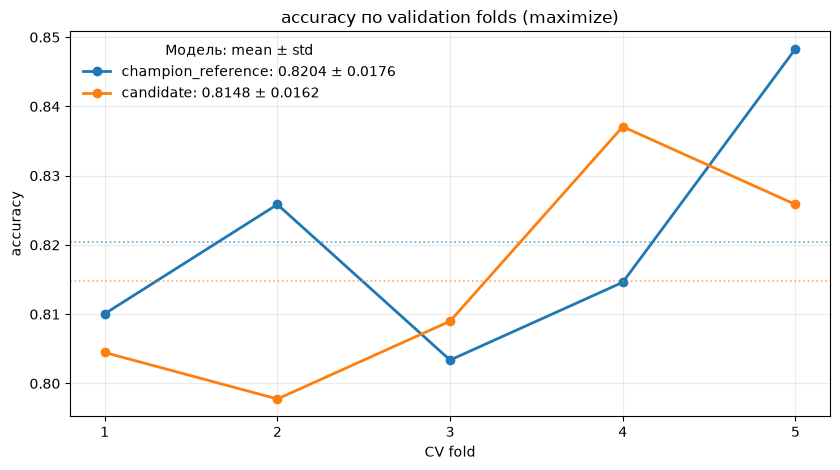

Метрика: Balanced accuracy


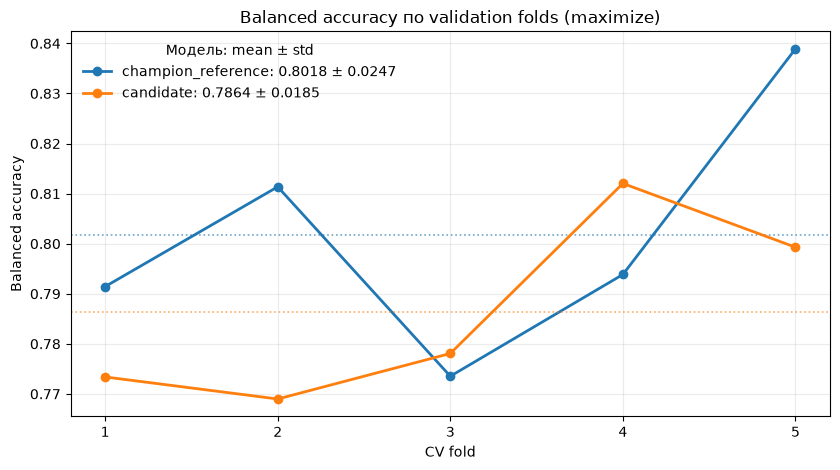

Метрика: Precision


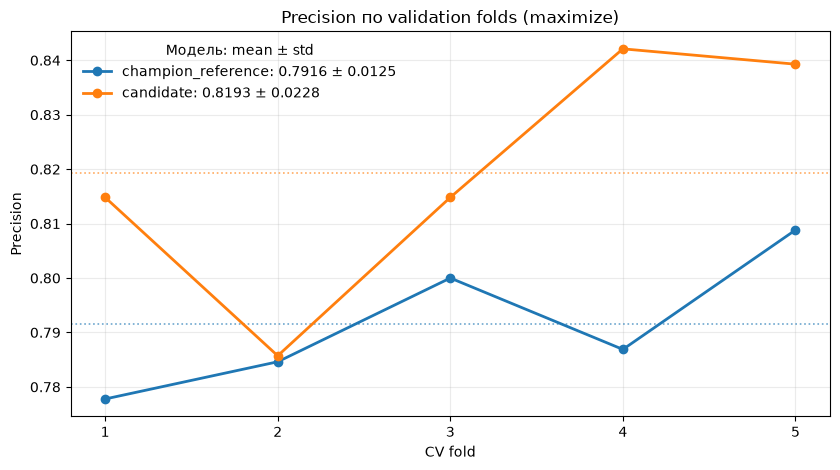

Метрика: Recall


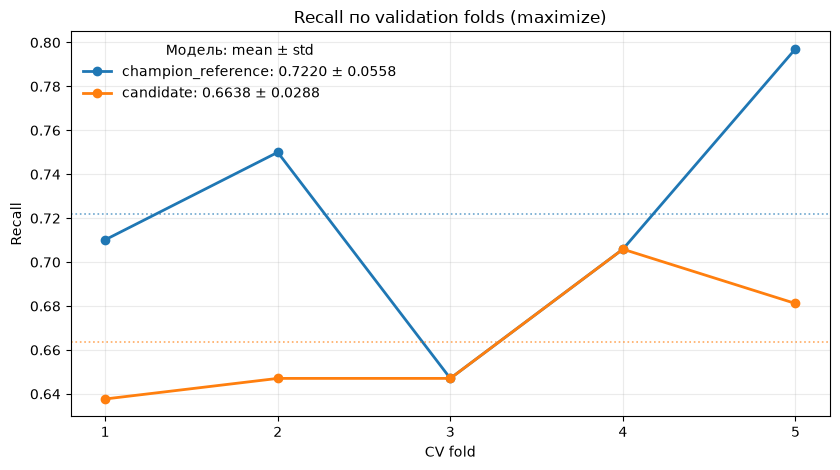

Метрика: F1


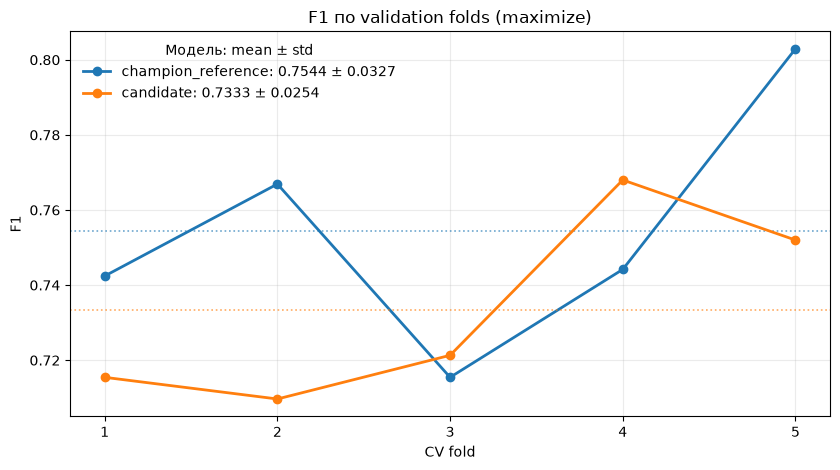

Метрика: ROC-AUC


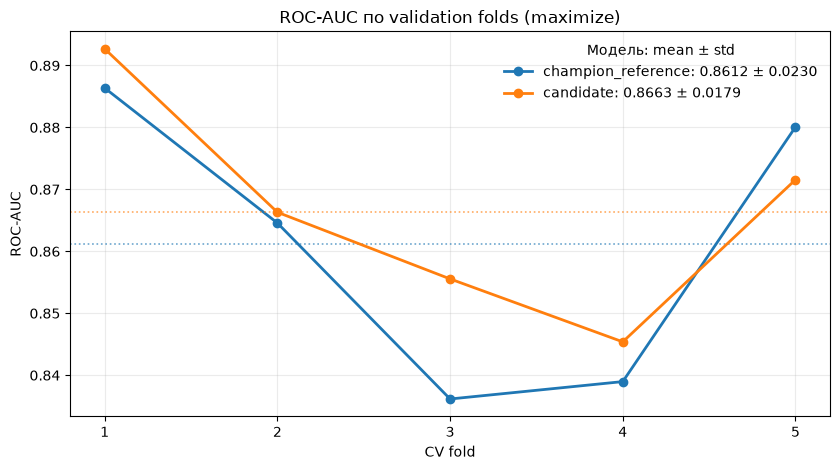

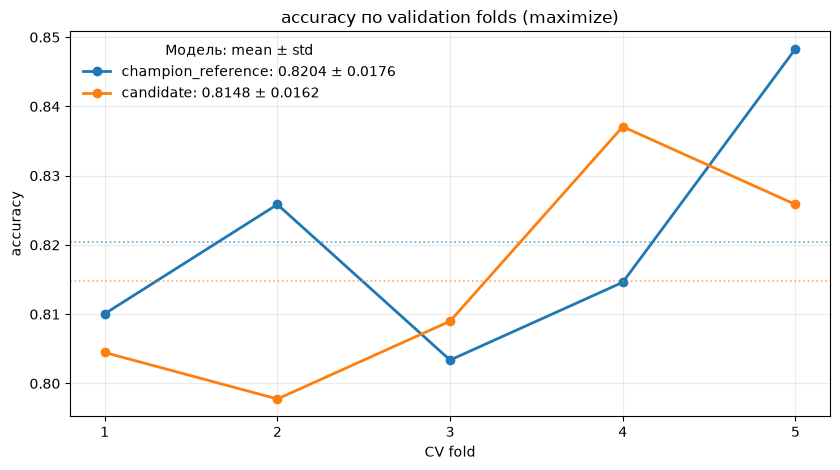

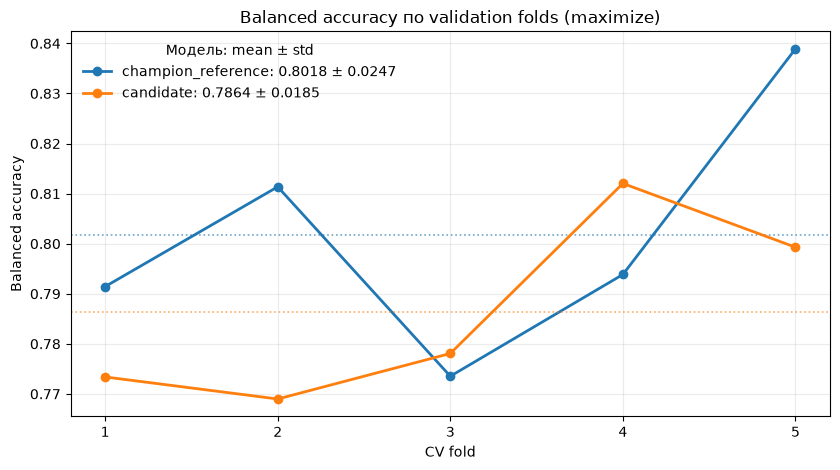

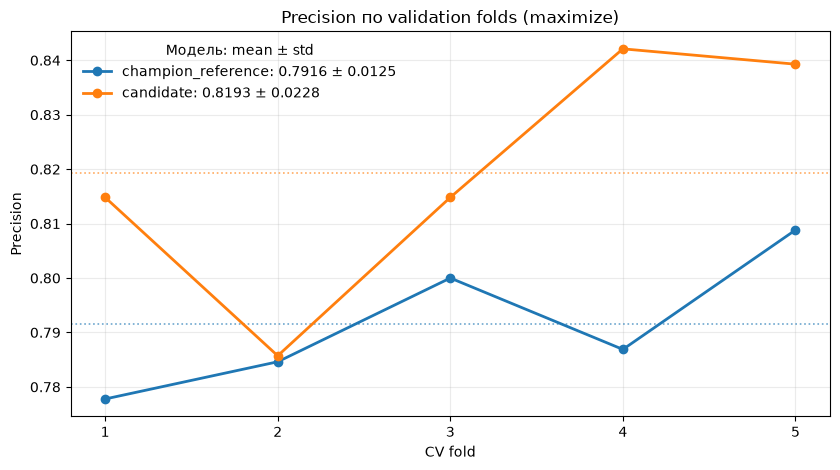

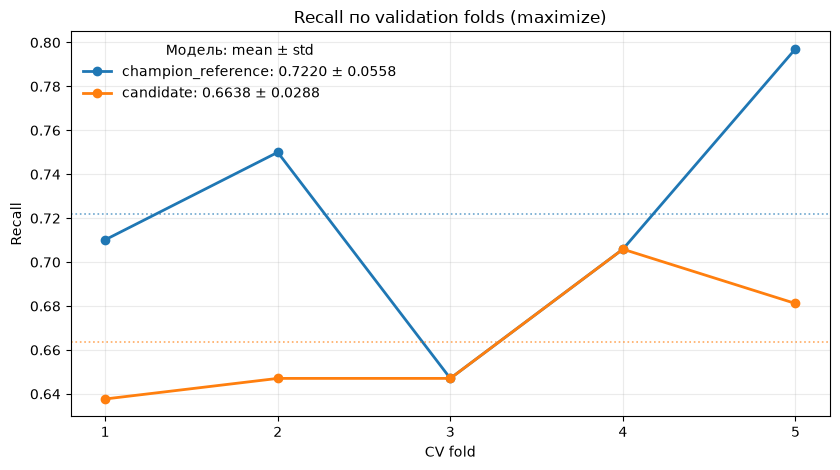

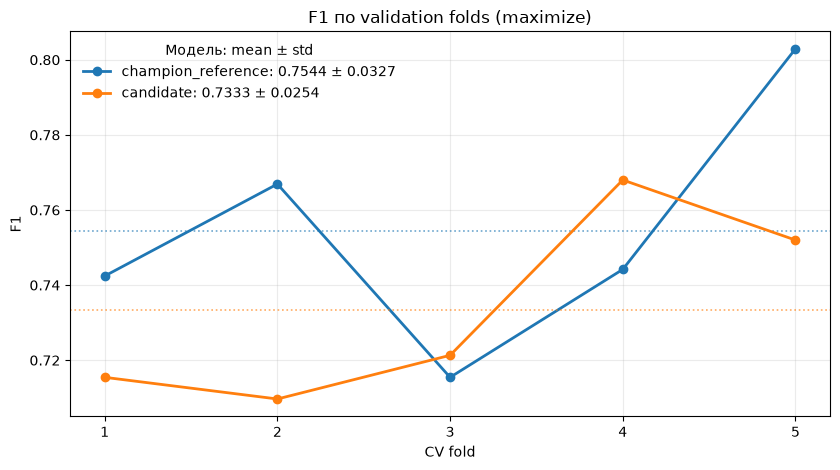

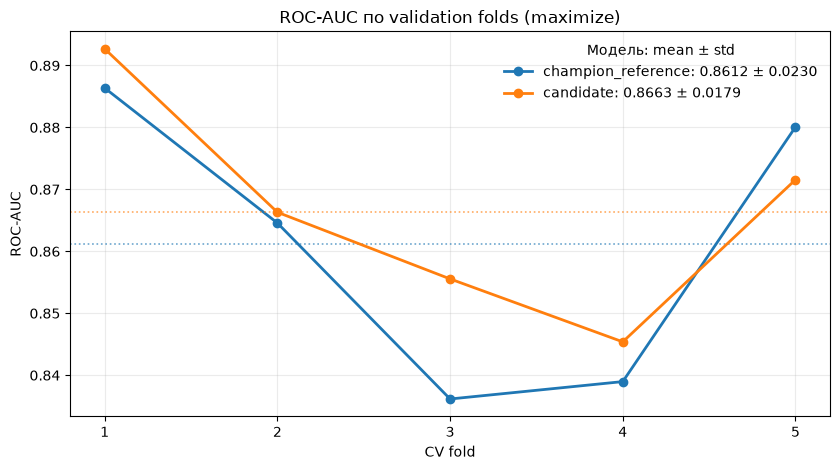

In [9]:
metric_figures = modeling_tools.build_metric_figures(
    evaluation,
    scoring_plan,
)
for metric_key, figure in metric_figures.items():
    print("Метрика:", scoring_plan.labels[metric_key])
    display(figure)


## 9. Сохранить артефакты и синхронизировать отчёты

Metadata получает полный dataset hash, путь и SHA-256 experiment-модуля,
формальные критерии и снимок окружения.


In [ ]:
saved_run = None
saved_diagnostics = None
write_requested = (
    experiment_settings.save_artifacts
    or experiment_settings.save_final_model
)
if write_requested:
    saved_run = experiment_tools.save_experiment_run(
        PROJECT_ROOT,
        experiment_settings,
        candidate_settings,
        evaluation,
        candidate_plan,
        scoring_plan,
        dataset_version=dataset_version,
        cv_description=cv_description,
        models=models,
        data=prepared,
        metric_figures=metric_figures,
        definition=experiment_definition,
    )
    print("Артефакты:", saved_run.run_dir.relative_to(PROJECT_ROOT))
    saved_diagnostics = modeling_tools.save_experiment_diagnostics(
        PROJECT_ROOT,
        diagnostics,
        experiment_settings,
    )
    print(
        "Диагностика:",
        saved_diagnostics.artifact_dir.relative_to(PROJECT_ROOT),
    )
else:
    print("Запись артефактов отключена.")

if experiment_settings.sync_experiment_note:
    if saved_run is None:
        print("Карточка не обновлена: сначала включите save_artifacts.")
    else:
        updated_note = experiment_tools.sync_experiment_note(
            PROJECT_ROOT,
            experiment_settings,
            evaluation,
            scoring_plan,
            saved_run,
            dataset_version=dataset_version,
            cv_description=cv_description,
            definition=experiment_definition,
            diagnostics=diagnostics,
            saved_diagnostics=saved_diagnostics,
        )
        print("Карточка:", experiment_settings.experiment_note, updated_note)

if experiment_settings.sync_docs:
    updated_docs = experiment_tools.sync_experiment_docs(
        PROJECT_ROOT,
        experiment_settings,
        evaluation,
        scoring_plan,
        initial_settings=initial_settings,
        dataset_version=dataset_version,
        definition=experiment_definition,
    )
    print("Docs/registry:", updated_docs)

report_issues = modeling_tools.audit_modeling_report(PROJECT_ROOT)
if report_issues:
    print("Проверка целостности отчёта:")
    for issue in report_issues:
        print("-", issue)
else:
    print("Проверка целостности отчёта: OK")


## 10. Решение и следующий эксперимент

### Закрыть текущий эксперимент

1. Объясните результат в созданной карточке.
2. Измените только `decision:` во frontmatter Markdown-карточки эксперимента.
3. Из корня проекта запустите `.\sync-experiment-state.cmd`; переобучение и повторный запуск notebook не требуются.
4. Полный `Run All` нужен только при изменении данных, признаков, модели или validation contract.

### Создать следующий эксперимент

Из корня проекта:

```powershell
.\new-experiment.cmd
```

Launcher сам предложит следующий ID, спросит название, slug, минимальный Δ
и guardrails, затем создаст новый модуль и выберет его в
`experiment_config.py`.
После заполнения `CHANGE ME`, candidate hooks и guardrails запустите этот
notebook сверху вниз. Старые experiment-модули не изменяются и остаются
точными воспроизводимыми спецификациями своих запусков.
